# CipherFace

In [1]:
%%capture
!pip install numpy deepface tenseal==0.3.16 tqdm lightphe chefboost

In [2]:
%%capture
# built-in dependencies
import os
import time
from typing import List
import pickle
import base64
import warnings
warnings.filterwarnings('ignore')


# 3rd party dependencies
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_pairs
from deepface import DeepFace
import tenseal as ts
import random
import torch


# metrics calculation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)
from sklearn.metrics import roc_curve, auc

2026-04-15 11:45:51.212848: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776253551.428181      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776253551.488698      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776253551.985182      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776253551.985233      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776253551.985237      55 computation_placer.cc:177] computation placer alr

In [3]:
def set_seed(seed: int = 42):
    # 1. Python
    random.seed(seed)

    # 2. Numpy
    np.random.seed(seed)

    # 3. PyTorch CPU
    torch.manual_seed(seed)

    # 4. PyTorch GPU
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 5. CuDNN (QUAN TRỌNG)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 6. Hash seed (Python internal)
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Seed set to {seed}")

In [4]:
set_seed(42)

Seed set to 42


In [5]:
print(f"Experiments done in DeepFace {DeepFace.__version__}")

Experiments done in DeepFace 0.0.99


In [6]:
detector_backend = "mtcnn"
model_name = "VGG-Face" # Set to "Facenet", "Facenet512" or "VGG-Face"
distance_metric = "euclidean" # Set to euclidean, cosine

In [7]:
def print_config(model_name, dist_metric, conf):
    print("-------CONFIG-------")
    print("Model name: ", model_name)
    print("Distance metric: ", dist_metric)
    print("Configure: ", conf)
    print("--------------------")
    

In [8]:
# tenseal cryptosystem configurations - these are all offering 128-bit security
configs = [
    (8192, [60, 40, 40, 60], 40),
    (16384, [31, 60, 60, 60, 60, 60, 60, 31], 60),
]

# set your crytosystem's configuration here
cs_config = configs[1]

In [9]:
print_config(model_name, distance_metric, cs_config)

-------CONFIG-------
Model name:  VGG-Face
Distance metric:  euclidean
Configure:  (16384, [31, 60, 60, 60, 60, 60, 60, 31], 60)
--------------------


# Prepare LFW Dataset

In [10]:
target_path = "/kaggle/working/lfwe/test"
lfw_input_file = "/kaggle/working/dataset/test_lfw.npy"
lfw_label_file = "/kaggle/working/dataset/test_labels.npy"

In [11]:
config = {
    "Facenet512": {
        "euclidean": 24.35,
        # "cosine": 0.026798495128309553,
        # "cosine": 0.02232566879533769,
        "cosine": 0.028744931705153496,
        
        
    },
    "Facenet": {
        "euclidean": 12.28,
        "cosine": 0.02431508799003538,
    },
    "VGG-Face": {
        "euclidean": 1.17,
        "cosine": 0.663973458216446,
    }
}

threshold = config[model_name][distance_metric]

In [12]:
os.makedirs(target_path, exist_ok=True)
os.makedirs("/kaggle/working/dataset", exist_ok=True)

In [13]:
%%time
if not os.path.exists(lfw_input_file):
    print("pulling LFW dataset")

    lfw_data = fetch_lfw_pairs(
        subset='test',
        color=True,
        resize=2,
        funneled=False
    )

    pairs = lfw_data.pairs
    labels = lfw_data.target

    np.save(lfw_input_file, pairs)
    np.save(lfw_label_file, labels)
    print("Done!!")
else:
    print("LFW dataset is already pulled")
    labels = np.load(lfw_label_file)

pulling LFW dataset
Done!!
CPU times: user 1min 27s, sys: 6.49 s, total: 1min 33s
Wall time: 1min 38s


In [14]:
%%time
for i in tqdm(range(0, 1000)):
    img1_target = f"{target_path}/{i}_1.jpg"
    img2_target = f"{target_path}/{i}_2.jpg"
    
    if os.path.exists(img1_target) is False:
        img1 = pairs[i][0]
        # plt.imsave(img1_target, img1/255) #works for my mac
        plt.imsave(img1_target, img1) #works for my debian
    
    if os.path.exists(img2_target) is False:
        img2 = pairs[i][1]
        # plt.imsave(img2_target, img2/255) #works for my mac
        plt.imsave(img2_target, img2) #works for my debian

100%|██████████| 1000/1000 [00:03<00:00, 284.59it/s]

CPU times: user 3.34 s, sys: 200 ms, total: 3.54 s
Wall time: 3.52 s


# Find Embeddings

In [15]:
def find_embeddings(img_path: str) -> List[list]:
    """
    Find embeddings of each face appearing in a given image
    Args:
        img_path (str): given input image
    Returns:
        results (list): embedding of each face
    """
    if os.path.exists(img_path) is False:
        raise ValueError(f"{img_path} not found")
    
    instances = []
    img_objs = DeepFace.represent(
        img_path = img_path,
        model_name = model_name,
        detector_backend = detector_backend,
        enforce_detection = False,
    )

    for img_obj in img_objs:
        embedding = img_obj["embedding"]
        instances.append(embedding)
    
    return instances

In [16]:
img_paths = []
for dirpath, dirnames, filenames in os.walk(target_path):
    for filename in filenames:
        img_path = f"{dirpath}/{filename}"
        img_paths.append(img_path)

In [17]:
print(f"there are {len(img_paths)} images available")

there are 2000 images available


In [18]:
%%time
embeddings_file = f"embeddings_{model_name}_{detector_backend}.pkl"

if os.path.exists(embeddings_file) is False:
    instances = []
    for img_path in tqdm(img_paths):
        embeddings = find_embeddings(img_path)
        for embedding in embeddings:
            instances.append((img_path, embedding))

    with open(embeddings_file, 'wb') as file:
        pickle.dump(instances, file)
else:
    print("embeddings calculated already")
    with open(embeddings_file, 'rb') as file:
        instances = pickle.load(file)

  0%|          | 0/2000 [00:00<?, ?it/s]2026-04-15 11:47:59.770641: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


26-04-15 11:48:01 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5

  0%|          | 0.00/580M [00:00<?, ?B/s]
  2%|▏         | 11.0M/580M [00:00<00:06, 86.7MB/s]
  4%|▎         | 21.5M/580M [00:00<00:05, 95.6MB/s]
  6%|▌         | 32.0M/580M [00:00<00:05, 95.8MB/s]
  7%|▋         | 42.5M/580M [00:00<00:05, 95.8MB/s]
  9%|▉         | 53.0M/580M [00:00<00:06, 85.3MB/s]
 11%|█         | 63.4M/580M [00:00<00:05, 90.0MB/s]
 13%|█▎        | 73.9M/580M [00:00<00:06, 81.3MB/s]
 15%|█▍        | 84.4M/580M [00:00<00:05, 87.2MB/s]
 16%|█▋        | 94.9M/580M [00:01<00:05, 91.9MB/s]
 18%|█▊        | 105M/580M [00:01<00:05, 83.7MB/s] 
 20%|█▉        | 116M/580M [00:01<00:05, 81.6MB/s]
 22%|██▏       | 126M/580M [00:01<00:05, 84.6MB/s]
 25%|██▌       | 147M/580M [00:01<00:04, 101MB/s] 
 27%|██▋       | 158M/580M [00:01<00:04, 95.7MB/s]
 29%|██▉       | 168M/580M [00:01<00:04, 92.5MB/s]
 31%|███       | 179M/580

CPU times: user 45min 56s, sys: 57.6 s, total: 46min 54s
Wall time: 18min 3s


In [19]:
# while calculating distance in euclidean, squared values calculated, so negative values are not a problem
# but negative values in embeddings confuse the homomorphic encryption, apply min max normalization
if distance_metric == "cosine":
    min_val = np.inf
    max_val = -np.inf
    for img_path, embedding in instances:
        for i in embedding:
            if i < min_val:
                min_val = i
            if i > max_val:
                max_val = i

    print(f"min: {min_val}, max: {max_val}")

    for img_path, embedding in instances:
        for i in range(len(embedding)):
            embedding[i] = ( (np.array(embedding[i]) - min_val) / (max_val - min_val) ).tolist()

In [20]:
# normalize vectors in advance for cosine similarity
norm_instances = []
if distance_metric == "cosine":
    for img_path, embedding in instances:
        norm = np.linalg.norm(embedding)
        norm_instances.append((img_path, embedding / norm))
    instances = norm_instances

# Performance On Plain Embeddings

In [21]:
columns = ["img_path", "embedding"]

df = pd.DataFrame(instances, columns = columns)

In [22]:
df.head()

,img_path,embedding
0,/kaggle/working/lfwe/test/775_2.jpg,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,/kaggle/working/lfwe/test/833_2.jpg,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,/kaggle/working/lfwe/test/138_2.jpg,"[0.09190001089344614, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,/kaggle/working/lfwe/test/491_2.jpg,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,/kaggle/working/lfwe/test/271_1.jpg,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [23]:
def find_euclidean_distance(
    source_representation: list, test_representation: list
) -> np.float64:
    """
    Find Euclidean distance between two vectors or batches of vectors.

    Args:
        source_representation (list): 1st vector or batch of vectors.
        test_representation (list): 2nd vector or batch of vectors.

    Returns:
        np.float64: Euclidean distance(s).
            Returns a np.float64 for single embeddings and np.ndarray for batch embeddings.
    """
    source_representation = np.asarray(source_representation)
    test_representation = np.asarray(test_representation)

    euclidean_distance = source_representation - test_representation
    euclidean_distance = np.sum(np.multiply(euclidean_distance, euclidean_distance))
    euclidean_distance = np.sqrt(euclidean_distance)

    return euclidean_distance

def find_cosine_distance(
    source_representation: list, test_representation: list
) -> np.float64:
    # Convert lists to numpy arrays for efficient computation
    source_vector = np.array(source_representation)
    test_vector = np.array(test_representation)
    
    # Compute the dot product
    dot_product = np.dot(source_vector, test_vector)
    
    # Compute the norms (magnitudes) of the vectors
    norm_source = np.linalg.norm(source_vector)
    norm_test = np.linalg.norm(test_vector)
    
    # Compute cosine similarity
    cosine_similarity = dot_product / (norm_source * norm_test)
    
    # Compute cosine distance
    cosine_distance = 1 - cosine_similarity
    return cosine_distance

def norm(x: list) -> np.ndarray:
    """
    Normalize input vector with l2
    Args:
        x (np.ndarray or list): given vector
    Returns:
        y (np.ndarray): l2 normalized vector
    """
    # x = np.array(x)
    # return x / np.sqrt(np.sum(np.multiply(x, x)))
    return np.linalg.norm(x)

In [24]:

pivot_distances = []
for i in tqdm(range(0, 1000)):
    img1_target = target_path +  f"/{i}_1.jpg"
    img2_target = target_path + f"/{i}_2.jpg"

    alphas = df[df["img_path"] == img1_target]["embedding"].values
    betas = df[df["img_path"] == img2_target]["embedding"].values

    
    # print("length of alphas: ",len(alphas))
    # print("length of betas: ",len(betas))
    distances = []
    for alpha in alphas:
        for beta in betas:
            if distance_metric == "euclidean":
                distance = find_euclidean_distance(alpha, beta)
            else:
                distance = find_cosine_distance(alpha, beta)
            distances.append(distance)
    
    distance = min(distances)
    pivot_distances.append(distance)

100%|██████████| 1000/1000 [00:01<00:00, 681.54it/s]


In [25]:
pivot = pd.DataFrame(pivot_distances, columns = ["distance"])
pivot["actual"] = labels

pivot["prediction"] = 0
tic = time.time()
idx = pivot[pivot["distance"] < threshold].index
pivot.loc[idx, "prediction"] = 1
toc = time.time()

In [26]:
pivot.head()

,distance,actual,prediction
0,0.646901,1,1
1,1.065599,1,1
2,0.963930,1,1
3,0.728650,1,1
4,0.990742,1,1


In [27]:
def cal_metrics(df):
    y_true = df["actual"]
    y_pred = df["prediction"]
    
    # Basic metrics
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("Confusion Matrix:\n", cm)
    
    # Full report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

In [28]:
def viz_cm(df):
    y_true = df["actual"]
    y_pred = df["prediction"]
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm, cmap = 'coolwarm')
    plt.title("Confusion Matrix")
    plt.colorbar()
    
    classes = ["Different", "Same"]
    tick_marks = np.arange(len(classes))
    
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    
    # show numbers
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
def viz_roc(df):
    y_true = df["actual"]
    y_pred = df["prediction"]
    
    y_scores = -df["distance"]  # smaller distance = more similar

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    
    plt.xlabel("False Positive Rate (FAR)")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    

In [ ]:
cal_metrics(pivot)

Accuracy: 0.945
Precision: 0.964509394572025
Recall: 0.924
F1-score: 0.9438202247191011
Confusion Matrix:
 [[483  17]
 [ 38 462]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       500
           1       0.96      0.92      0.94       500

    accuracy                           0.94      1000
   macro avg       0.95      0.95      0.94      1000
weighted avg       0.95      0.94      0.94      1000



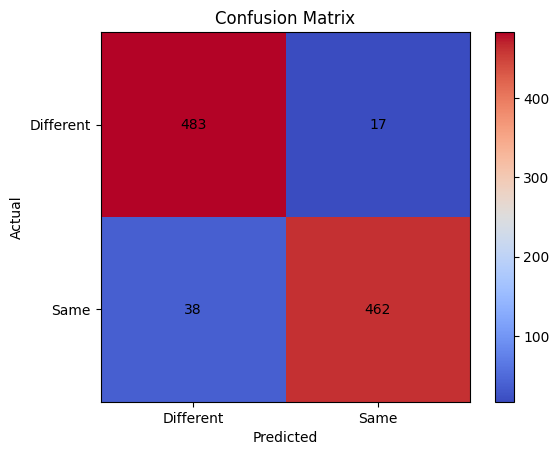

In [ ]:
viz_cm(pivot)

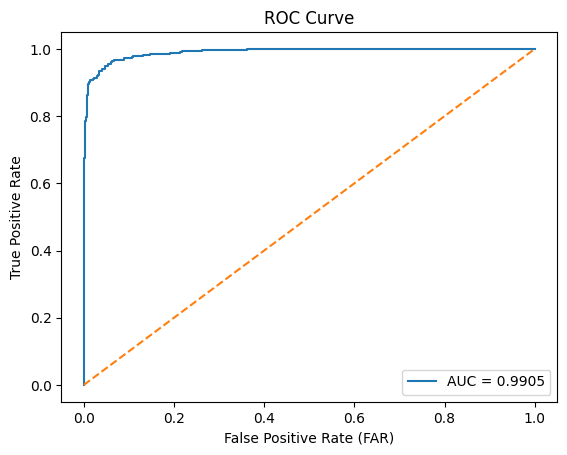

In [ ]:
viz_roc(pivot)

In [ ]:

# to find the best threshold
if True:
    tmp_df = pivot[["distance", "actual"]].copy()
    idx = tmp_df[tmp_df["actual"] == 1].index
    tmp_df["Decision"] = "Different Persons"
    tmp_df.loc[idx, "Decision"] = "Same Person"
    tmp_df = tmp_df.drop(columns = ["actual"])

    from chefboost import Chefboost
    chef_model = Chefboost.fit(tmp_df)
    print(chef_model["trees"])

26-04-15 12:06:05 - ID3 tree is going to be built...
26-04-15 12:06:06 - -------------------------
26-04-15 12:06:06 - finished in 0.9102780818939209 seconds
26-04-15 12:06:06 - -------------------------
26-04-15 12:06:06 - Evaluate train set
26-04-15 12:06:06 - -------------------------
26-04-15 12:06:06 - Accuracy: 93.7% on 1000 instances
26-04-15 12:06:06 - Labels: ['Same Person' 'Different Persons']
26-04-15 12:06:06 - Confusion matrix: [[442, 5], [58, 495]]
26-04-15 12:06:06 - Precision: 98.8814%, Recall: 88.4%, F1: 93.3474%
[<module 'outputs.rules.rules' from '/kaggle/working/outputs/rules/rules.py'>]


In [ ]:
chef_model

{'trees': [<module 'outputs.rules.rules' from '/kaggle/working/outputs/rules/rules.py'>],
 'alphas': [],
 'config': {'algorithm': 'ID3',
  'enableRandomForest': False,
  'num_of_trees': 5,
  'enableMultitasking': False,
  'enableGBM': False,
  'epochs': 10,
  'learning_rate': 1,
  'max_depth': 5,
  'enableAdaboost': False,
  'num_of_weak_classifier': 4,
  'enableParallelism': False,
  'num_cores': 2},
 'nan_values': [['distance', None]],
 'evaluation': {'train': {'Accuracy': 93.7,
   'Instances': 1000,
   'Labels': array(['Same Person', 'Different Persons'], dtype=object),
   'Confusion matrix': [[442, 5], [58, 495]],
   'Precision': 98.8814,
   'Recall': 88.4,
   'F1': 93.3474}}}

In [ ]:
print(f"verification requires an additional {toc - tic} seconds")

verification requires an additional 0.0020782947540283203 seconds


<Axes: ylabel='Density'>

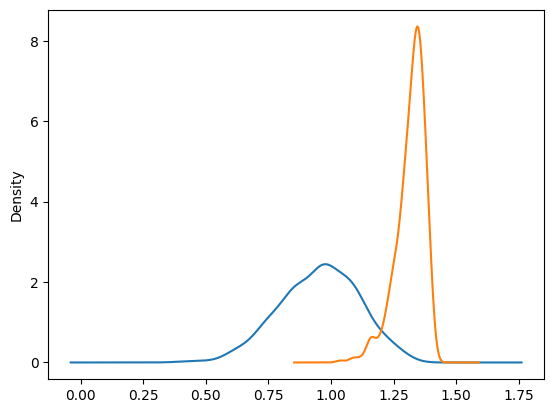

In [ ]:
pivot[pivot.actual == 1].distance.plot.kde()
pivot[pivot.actual == 0].distance.plot.kde()

In [ ]:
accuracy = 100 * len(pivot[pivot["actual"] == pivot["prediction"]]) / 1000
accuracy

94.5

# Initialize Homomorphic Enryption Object

In [ ]:
def write_data(file_name, data):
    if type(data) == bytes:
        #bytes to base64
        data = base64.b64encode(data)
        
    with open(file_name, 'wb') as f: 
        f.write(data)

def read_data(file_name):
    with open(file_name, "rb") as f:
        data = f.read()
    
    #base64 to bytes
    return base64.b64decode(data)

In [ ]:
mod, coeff, scale = cs_config
context = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree = mod,
            coeff_mod_bit_sizes = coeff
          )
context.generate_galois_keys()
context.global_scale = 2**scale

secret_context = context.serialize(save_secret_key = True)
write_data("secret.txt", secret_context)

context.make_context_public() #drop the secret_key from the context
public_context = context.serialize()
write_data("public.txt", public_context)

del context, secret_context, public_context

# Encryption

In [ ]:
context = ts.context_from(read_data("secret.txt"))
# context = ts.context_from(read_data("public.txt")) # encryption can be done with public key, too

In [ ]:
encrypted_embeddings = []

start_time = time.time()

for index, instance in tqdm(df.iterrows(), total=df.shape[0]):
    img_path = instance["img_path"]

    embedding = instance["embedding"]
    enc_v1 = ts.ckks_vector(context, embedding)
    encrypted_embedding = enc_v1.serialize()
    encrypted_embeddings.append(encrypted_embedding)

end_time = time.time()

# compute ms/it
total_time = end_time - start_time  # seconds
ms_per_it = 1000 * (total_time) / df.shape[0]  # milliseconds per iteration

print(f"Total time: {total_time:.4f} s")
print(f"ms/it: {ms_per_it:.4f}")

100%|██████████| 2000/2000 [01:14<00:00, 26.67it/s]

Total time: 74.9886 s
ms/it: 37.4943


In [ ]:
encrypted_df = df.copy()
encrypted_df = encrypted_df.drop(columns = ["embedding"])
encrypted_df["encrypted_embedding"] = encrypted_embeddings

In [ ]:
encrypted_df.head()

,img_path,encrypted_embedding
0,/kaggle/working/lfwe/test/775_2.jpg,b'\n\x02\x80 \x12\x89\xdeh^\xa1\x10\x04\x01\x0...
1,/kaggle/working/lfwe/test/833_2.jpg,b'\n\x02\x80 \x12\xf2\xddh^\xa1\x10\x04\x01\x0...
2,/kaggle/working/lfwe/test/138_2.jpg,b'\n\x02\x80 \x12\xc3\xddh^\xa1\x10\x04\x01\x0...
3,/kaggle/working/lfwe/test/491_2.jpg,b'\n\x02\x80 \x12\xa9\xddh^\xa1\x10\x04\x01\x0...
4,/kaggle/working/lfwe/test/271_1.jpg,b'\n\x02\x80 \x12\xcc\xddh^\xa1\x10\x04\x01\x0...


In [ ]:
del context, enc_v1, encrypted_embedding

# Homomorphic Calculations

In [ ]:
context = ts.context_from(read_data("public.txt"))

In [ ]:
one = ts.ckks_vector(context, [1])
one.link_context(context)

In [ ]:
calculations = []

start_time = time.time()

for i in tqdm(range(0, 1000)):
    img1_target = target_path +  f"/{i}_1.jpg"
    img2_target = target_path + f"/{i}_2.jpg"

    alphas_idxs = encrypted_df[encrypted_df["img_path"] == img1_target].index
    betas_idxs = encrypted_df[encrypted_df["img_path"] == img2_target].index

    encrypted_distances = []
    encrypted_distance_denominators = []
    for alphas_idx in alphas_idxs:
        alpha_proto = encrypted_df.loc[alphas_idx]["encrypted_embedding"]
        alpha = ts.lazy_ckks_vector_from(alpha_proto)
        alpha.link_context(context)

        for betas_idx in betas_idxs:
            beta_proto = encrypted_df.loc[betas_idx]["encrypted_embedding"]
            beta = ts.lazy_ckks_vector_from(beta_proto)
            beta.link_context(context)

            if distance_metric == "euclidean":
                difference = alpha - beta
                encrypted_distance = difference.dot(difference)

                # if you try to decrypt it here, you will get exception because you don't have the private key
                # encrypted_squared_distance.decrypt()

            else:
                encrypted_distance = one - alpha.dot(beta)
            
            encrypted_distance = encrypted_distance.serialize()
            encrypted_distances.append(encrypted_distance)

    calculations.append((img1_target, img2_target, encrypted_distances))

end_time = time.time()

# compute ms/it
total_time = end_time - start_time  # seconds
ms_per_it = 1000 * (total_time) / 1000  # milliseconds per iteration

print(f"Total time: {total_time:.4f} s")
print(f"ms/it: {ms_per_it:.4f}")

100%|██████████| 1000/1000 [05:58<00:00,  2.79it/s]

Total time: 358.4658 s
ms/it: 358.4658


In [ ]:
del context, alpha_proto, beta_proto, alpha, beta

# Decryption

In [ ]:
context = ts.context_from(read_data("secret.txt"))

In [ ]:
distances = []

start_time = time.time()

for img1_path, img2_path, encrypted_distances in tqdm(calculations):

    current_distances = []
    for encrypted_distance_proto in encrypted_distances:
        encrypted_distance = ts.lazy_ckks_vector_from(encrypted_distance_proto)
        encrypted_distance.link_context(context)

        distance = encrypted_distance.decrypt()[0]

        current_distances.append(distance)
    
    distances.append(min(current_distances))


end_time = time.time()

# compute ms/it
total_time = end_time - start_time  # seconds
ms_per_it = 1000 * (total_time) / len(calculations)  # milliseconds per iteration

print(f"Total time: {total_time:.4f} s")
print(f"ms/it: {ms_per_it:.4f}")

100%|██████████| 1000/1000 [00:14<00:00, 70.19it/s]

Total time: 14.2517 s
ms/it: 14.2517


In [ ]:
results_df = pd.DataFrame(labels, columns = ["actual"])
results_df["distance"] = distances
if distance_metric == "euclidean":
    results_df["threshold"] = threshold * threshold
else:
    results_df["threshold"] = threshold

results_df["prediction"] = 0
tic = time.time()
idx = results_df[results_df["distance"] <= results_df["threshold"]].index
results_df.loc[idx, "prediction"] = 1
toc = time.time()

In [ ]:
print(f"verification requires an additional {toc - tic} seconds")

verification requires an additional 0.003260374069213867 seconds


In [ ]:
results_df.head()

,actual,distance,threshold,prediction
0,1,0.414813,1.3689,1
1,1,1.131275,1.3689,1
2,1,0.925054,1.3689,1
3,1,0.526883,1.3689,1
4,1,0.977601,1.3689,1


In [ ]:
results_df.iloc[22]

actual        1.000000
distance      1.364519
threshold     1.368900
prediction    1.000000
Name: 22, dtype: float64

In [ ]:
cal_metrics(results_df)

Accuracy: 0.946
Precision: 0.9645833333333333
Recall: 0.926
F1-score: 0.9448979591836735
Confusion Matrix:
 [[483  17]
 [ 37 463]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       500
           1       0.96      0.93      0.94       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



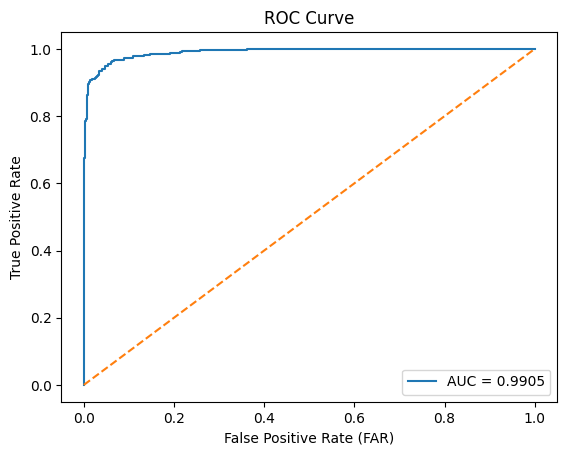

In [ ]:
viz_roc(results_df)

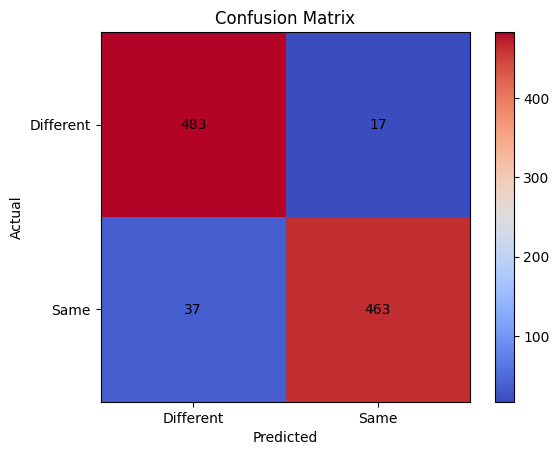

In [ ]:
viz_cm(results_df)

In [ ]:
homomorphic_accuracy = (100 * len(results_df[results_df["actual"] == results_df["prediction"]]) / 1000)
print(f"accuracy was {accuracy} in plain verification whereas it is {homomorphic_accuracy}")

accuracy was 94.5 in plain verification whereas it is 94.6
